# Wine 데이터셋 GMM 클러스터링

## 개요
- Wine 데이터셋에 Gaussian Mixture Model (GMM) 적용
- 확률 기반 Soft Clustering 수행
- 가우시안 분포로 각 군집 모델링

## 주요 단계
1. 데이터 로드 및 정규화
2. PCA 차원 축소 (13차원 → 2차원)
3. GMM 모델 학습 및 예측
4. 결과 시각화

## 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

## 1. 데이터 로드 및 전처리

- Wine 데이터셋: 178개 샘플, 13개 피처
- GMM은 데이터 분산에 민감하므로 스케일링 권장

In [2]:
# 와인 데이터셋 로드
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)

# 데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"데이터 크기: {X.shape}")
print(f"\n데이터 샘플:\n{X.head()}")

데이터 크기: (178, 13)

데이터 샘플:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  pr

## 2. 차원 축소 (PCA)

- 13차원 → 2차원 축소
- 시각화 및 연산 효율화

In [3]:
# PCA 적용
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"설명된 분산 비율: {pca.explained_variance_ratio_}")
print(f"총 설명된 분산: {sum(pca.explained_variance_ratio_):.2%}")

설명된 분산 비율: [0.36198848 0.1920749 ]
총 설명된 분산: 55.41%


## 3. GMM 모델 생성 및 학습

**GMM 파라미터**
- n_components=3: 군집 개수 (와인 데이터의 실제 클래스 수)
- random_state=42: 결과 재현성을 위한 시드값 고정

**Soft Clustering**
- fit: 데이터의 확률 분포 학습
- predict: 가장 높은 확률의 군집 할당
- predict_proba: 각 군집에 속할 확률 계산 (Soft Clustering)

In [4]:
# GMM 모델 설정 및 학습
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_pca)

# 군집 예측
labels = gmm.predict(X_pca)

print(f"발견된 군집 개수: {len(np.unique(labels))}")
print(f"\n군집 중심점 (평균):\n{gmm.means_}")

발견된 군집 개수: 3

군집 중심점 (평균):
[[-0.13663617 -1.71241678]
 [-2.7667918   1.23902362]
 [ 2.26611726  0.90317491]]


**군집별 샘플 개수**

In [5]:
# 각 군집별 샘플 개수
for k in range(3):
    count = np.sum(labels == k)
    print(f"클러스터 {k}: {count}개")

클러스터 0: 68개
클러스터 1: 48개
클러스터 2: 62개


**Soft Clustering 확률 확인 (선택사항)**

각 데이터 포인트가 각 군집에 속할 확률을 확인할 수 있습니다.

In [6]:
# 각 군집에 속할 확률 계산
probs = gmm.predict_proba(X_pca)

print("첫 5개 샘플의 군집별 소속 확률:")
print("Sample | Cluster 0 | Cluster 1 | Cluster 2")
print("-" * 45)
for i in range(5):
    print(f"  {i:2d}   | {probs[i,0]:9.6f} | {probs[i,1]:9.6f} | {probs[i,2]:9.6f}")

첫 5개 샘플의 군집별 소속 확률:
Sample | Cluster 0 | Cluster 1 | Cluster 2
---------------------------------------------
   0   |  0.000000 |  0.000000 |  1.000000
   1   |  0.039984 |  0.000000 |  0.960016
   2   |  0.000017 |  0.000000 |  0.999983
   3   |  0.000000 |  0.000000 |  1.000000
   4   |  0.003560 |  0.000000 |  0.996440


## 4. 결과 시각화

- 원형 마커: 군집별 데이터 포인트
- 붉은색 별: 가우시안 분포의 중심점(평균)

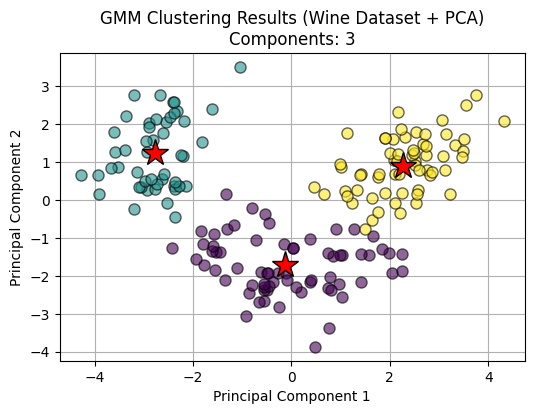

In [11]:
plt.figure(figsize=(6, 4))

# 군집 중심점(평균) 추출
centers = gmm.means_

# 군집별 색상 생성
colors = plt.cm.viridis(np.linspace(0, 1, 3))

for k, col in zip(range(3), colors):
    my_members = (labels == k)

    # 군집 데이터 포인트
    plt.plot(X_pca[my_members, 0], X_pca[my_members, 1], 'o',
             markerfacecolor=col, markeredgecolor='k', markersize=8, alpha=0.6)

    # 가우시안 분포의 중심점
    plt.plot(centers[k, 0], centers[k, 1], '*',
             markerfacecolor='red', markeredgecolor='k', markersize=20)

plt.title('GMM Clustering Results (Wine Dataset + PCA)\nComponents: 3')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

## 원본 레이블 비교

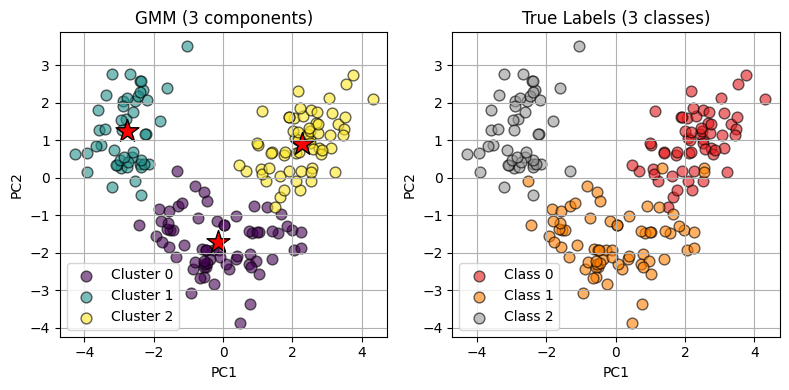

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# GMM 결과
colors_gmm = plt.cm.viridis(np.linspace(0, 1, 3))
for k, col in zip(range(3), colors_gmm):
    my_members = (labels == k)
    axes[0].scatter(X_pca[my_members, 0], X_pca[my_members, 1],
                   c=[col], label=f'Cluster {k}', s=60, edgecolors='k', alpha=0.6)
    axes[0].scatter(centers[k, 0], centers[k, 1],
                   marker='*', c='red', s=300, edgecolors='k')
axes[0].set_title('GMM (3 components)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True)

# 원본 레이블
colors_true = plt.cm.Set1(np.linspace(0, 1, len(np.unique(wine.target))))
for k, col in zip(np.unique(wine.target), colors_true):
    my_members = (wine.target == k)
    axes[1].scatter(X_pca[my_members, 0], X_pca[my_members, 1],
                   c=[col], label=f'Class {k}', s=60, edgecolors='k', alpha=0.6)
axes[1].set_title(f'True Labels ({len(np.unique(wine.target))} classes)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()